# 04 — Global ML forecasting

Per-clinic models treat each series as an island. A **global model** pools the
panel and learns one function from features to demand, which changes the
economics and the statistics at once:

- **Statistical strength is shared.** Clinic-specific behaviour is encoded as
  features (identity, size, specialty, weekday interactions), so clinics with
  noisy history borrow structure from the rest of the network.
- **Cost is constant in the number of series.** One training run serves 12 or
  200 clinics; this is what makes the approach production-realistic.
- **Nonlinearities come free.** Tree ensembles capture the diminishing-returns
  marketing response and holiday interactions that linear exogenous terms
  approximate.

The wrapper is `clinic_forecast.models.global_ml.GlobalMLForecaster` —
scikit-learn's `HistGradientBoostingRegressor` by default, XGBoost as an
optional drop-in. Evaluation reuses the exact folds from notebook 03.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])

print(usage.shape)

(17532, 32)


## Feature design and leakage discipline

Features fall into four groups, all leakage-safe by construction:

| Group | Features | Known at forecast time because... |
|---|---|---|
| History | lags 1/7/14/28, rolling mean/std 7/14/28, expanding mean | computed on the one-step-*shifted* series, per clinic — windows never include the current day and never cross clinic boundaries |
| Calendar | day-of-week, month, week, holiday flag, opening calendar | deterministic |
| Marketing | same-day spend, spend lags 1/7, 7-day rolling spend | budgets are planned ahead; same-day spend is a known input |
| Metadata | clinic identity, size, specialty, region (one-hot) | static |

Same-day operational *outcomes* (no-shows, cancellations, utilisation,
scheduled appointments) are explicitly excluded — they are only known after
the day has happened.

Two prediction modes matter:

- **`predict_known_future`** (used for backtesting): test-window lag features
  come from actuals that would have been observed by each forecast day.
- **`forecast`** (deployment mode): the future has no targets at all;
  predictions are fed back recursively as lag inputs, one day at a time.
  Demonstrated at the end of this notebook.

In [3]:
from clinic_forecast.evaluation import comparison_table, evaluate_forecasts
from clinic_forecast.models.baseline import seasonal_naive_forecast
from clinic_forecast.models.global_ml import GlobalMLForecaster
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)
splitter.summary(usage)

,fold_id,train_start,train_end,test_start,test_end,train_days,test_days,train_rows,test_rows
0,1,2022-01-01,2024-12-30,2024-12-31,2025-01-27,1095,28,13140,336
1,2,2022-01-01,2025-01-27,2025-01-28,2025-02-24,1123,28,13476,336
2,3,2022-01-01,2025-02-24,2025-02-25,2025-03-24,1151,28,13812,336


## Rolling-origin comparison against the baseline

The model is refit from scratch inside every fold — no information crosses
fold boundaries. Seasonal naive is scored on identical data.

In [4]:
scored_folds = []
for train, test, fold in splitter.split(usage):
    model = GlobalMLForecaster()
    model.fit(train)

    combined = pd.concat([train, test], ignore_index=True).sort_values(["clinic_id", "date"])
    predictions = model.predict_known_future(combined)
    predictions = predictions[predictions["date"] >= fold.test_start]

    scored = test.merge(
        predictions[["clinic_id", "date", "forecast", "model"]],
        on=["clinic_id", "date"], how="inner",
    )
    scored_naive = test.merge(
        seasonal_naive_forecast(train=train, future=test),
        on=["clinic_id", "date"], how="left",
    )
    for frame in (scored, scored_naive):
        frame["fold"] = fold.fold_id
    scored_folds.extend([scored, scored_naive])

scored_folds = pd.concat(scored_folds, ignore_index=True)
fold_metrics = evaluate_forecasts(scored_folds, group_cols=["fold"])
fold_metrics.pivot(index="fold", columns="model", values=["wape", "bias"]).round(2)

wape                         bias               
model global_ml_hgb seasonal_naive global_ml_hgb seasonal_naive
fold                                                           
1             22.58          50.04          1.80         -37.31
2             20.66          27.09         -3.20          -8.30
3             20.68          27.08         -0.38           8.95

In [5]:
wide = fold_metrics.pivot(index="fold", columns="model", values="wape")
improvement = 1 - wide["global_ml_hgb"] / wide["seasonal_naive"]
print("WAPE improvement over seasonal naive: "
      + ", ".join(f"fold {i}: {v:.0%}" for i, v in improvement.items()))

last_fold_id = scored_folds["fold"].max()
last_scored = scored_folds[
    (scored_folds["fold"] == last_fold_id) & (scored_folds["model"] == "global_ml_hgb")
]

WAPE improvement over seasonal naive: fold 1: 55%, fold 2: 24%, fold 3: 24%


Read the table fold by fold, not just on average:

- The improvement over the naive baseline should hold on *every* fold; a
  model that wins on average but loses on a fold is fragile.
- Compare bias columns. The naive method's bias swings with whichever week it
  happened to copy; the model's bias is smaller and more stable. Bias
  stability matters more than a point of WAPE for staffing, because
  systematic under-forecasting compounds into chronic understaffing.
- The model's small persistent negative bias is the documented capacity-
  censoring effect: on peak days the recorded "actuals" are themselves capped.

## Adding the statistical reference: SARIMAX on the final fold

Notebook 03 fit SARIMAX on three clinics for cost reasons. For a fair
three-way comparison we fit it per clinic on the full network for the final
fold only — accepting the ~minute of per-series fitting that the global model
avoids.

In [6]:
from clinic_forecast.models.sarimax import sarimax_panel_forecast

*_, (final_train, final_test, final_fold) = splitter.split(usage)
sarimax_fcst = sarimax_panel_forecast(
    train=final_train,
    future=final_test,
    exog_cols=["marketing_spend", "campaign_active", "is_holiday"],
)
scored_sarimax = final_test.merge(sarimax_fcst, on=["clinic_id", "date"], how="left")

final_three_way = pd.concat(
    [
        last_scored,
        scored_sarimax,
        final_test.merge(
            seasonal_naive_forecast(train=final_train, future=final_test),
            on=["clinic_id", "date"], how="left",
        ),
    ],
    ignore_index=True,
)
comparison_table(evaluate_forecasts(final_three_way))

,mae,rmse,wape,bias
model,,,,
global_ml_hgb,17.606,23.663,20.681,-0.376
sarimax,19.043,25.887,22.368,8.348
seasonal_naive,23.051,32.467,27.076,8.946


The ordering — global ML, then SARIMAX, then naive — holds on this data, and
the gap between the global model and SARIMAX is the value of pooled,
nonlinear features. The gap between SARIMAX and naive is the value of any
model at all. Both gaps should be quoted when making the business case.

## Per-clinic performance

A global model can hide poor performance on individual clinics behind a good
volume-weighted average. The distribution below is the check; in a healthcare
network, consistently mis-served clinics are an operational and equity
problem even when the network number looks fine.

In [7]:
clinic_metrics = (
    evaluate_forecasts(last_scored, group_cols=["clinic_id"])
    .sort_values("wape")
    .reset_index(drop=True)
)
clinic_metrics[["clinic_id", "mae", "rmse", "wape", "bias", "n_obs"]].round(2)

,clinic_id,mae,rmse,wape,bias,n_obs
0,CLINIC_012,23.72,29.60,15.17,0.95,28
1,CLINIC_011,14.88,18.99,17.52,-4.05,28
2,CLINIC_002,32.30,38.19,17.97,-2.14,28
3,CLINIC_007,22.01,26.77,19.05,-4.54,28
4,CLINIC_008,9.60,12.60,20.51,4.97,28
5,CLINIC_010,20.58,29.00,20.84,5.94,28
6,CLINIC_006,19.18,23.01,23.77,-4.23,28
7,CLINIC_001,18.34,23.17,25.84,-0.10,28
8,CLINIC_004,14.57,19.53,25.86,6.46,28
9,CLINIC_009,19.10,24.49,26.19,-4.65,28


In [8]:
spread = clinic_metrics["wape"].max() / clinic_metrics["wape"].min()
print(f"WAPE spread across clinics (final fold): "
      f"{clinic_metrics['wape'].min():.1f}% to {clinic_metrics['wape'].max():.1f}% "
      f"({spread:.1f}x)")

WAPE spread across clinics (final fold): 15.2% to 29.2% (1.9x)


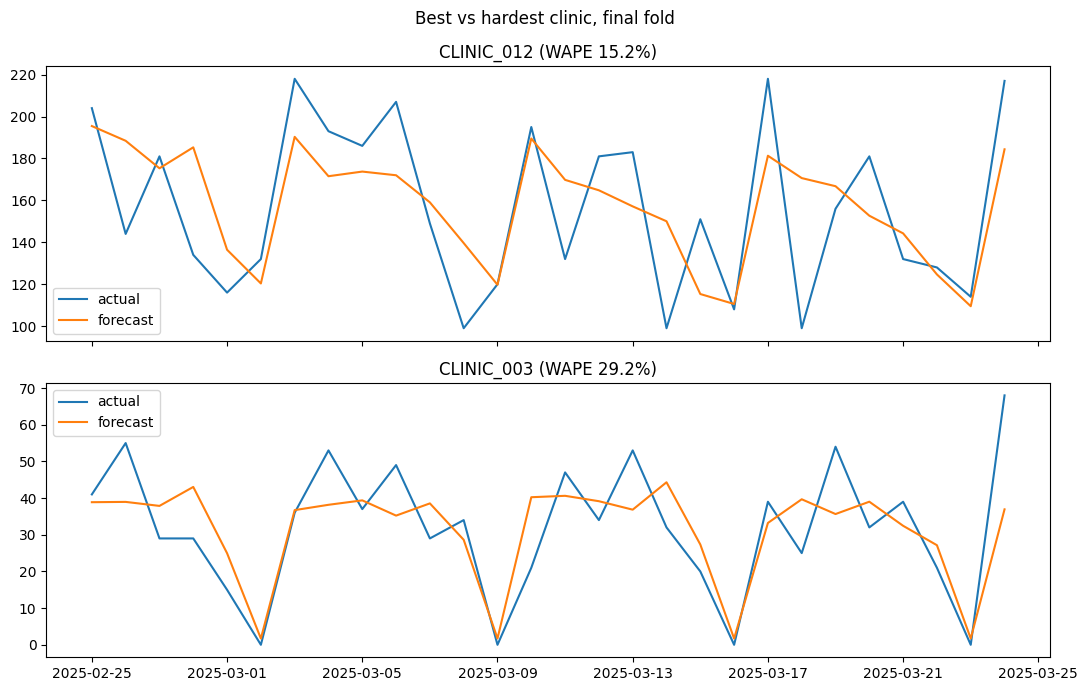

In [9]:
worst = clinic_metrics.iloc[-1]["clinic_id"]
best = clinic_metrics.iloc[0]["clinic_id"]
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, clinic in zip(axes, [best, worst]):
    frame = last_scored[last_scored["clinic_id"] == clinic]
    ax.plot(frame["date"], frame["visits"], label="actual")
    ax.plot(frame["date"], frame["forecast"], label="forecast")
    wape = clinic_metrics.set_index("clinic_id").loc[clinic, "wape"]
    ax.set_title(f"{clinic} (WAPE {wape:.1f}%)")
    ax.legend()
fig.suptitle("Best vs hardest clinic, final fold")
fig.tight_layout()
plt.show()

Cross-reference with the forecastability table in notebook 02 — the high-CV,
episode-prone clinics are the same ones at the bottom here, which says the
model is extracting the structure that exists rather than underfitting
specific clinics.

## What drives the forecasts: permutation importance

Permutation importance asks "how much worse does the model get if this
feature's values are shuffled?" — a model-agnostic answer that, unlike tree
split counts, accounts for feature interactions and correlated inputs.

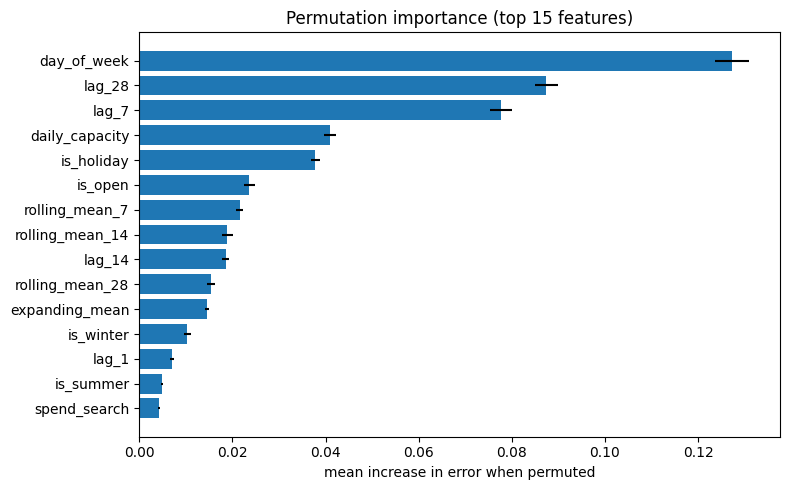

In [10]:
importance = model.permutation_importance_frame(
    pd.concat([train.tail(5000), test]), n_repeats=5, top_n=15
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance["feature"][::-1], importance["importance_mean"][::-1],
        xerr=importance["importance_std"][::-1])
ax.set_title("Permutation importance (top 15 features)")
ax.set_xlabel("mean increase in error when permuted")
fig.tight_layout()
plt.show()

The expected hierarchy appears: recent history (lag 1/7, short rolling means)
dominates, the calendar features carry the structural cycles, and marketing
features contribute a small but real amount. Clinic one-hots matter little
*because* the lag features already encode each clinic's level — identity
features would matter far more for cold-start clinics with no history.

## Deployment mode: recursive multi-step forecasting

Backtesting can use observed actuals to build test-window lags. Deployment
cannot: forecasting 28 days ahead means day 14's lag-7 feature is itself a
forecast. `forecast()` feeds predictions back day by day.

The comparison below measures the cost of recursion: known-future mode is an
optimistic bound, recursive mode is what production would actually see.

In [11]:
future = final_test.drop(columns=["visits"])
recursive = model.forecast(history=final_train, future=future)
scored_recursive = final_test.merge(
    recursive[["clinic_id", "date", "forecast"]], on=["clinic_id", "date"], how="left"
).assign(model="global_ml_recursive")

modes = pd.concat([last_scored, scored_recursive], ignore_index=True)
comparison_table(evaluate_forecasts(modes))

,mae,rmse,wape,bias
model,,,,
global_ml_hgb,17.606,23.663,20.681,-0.376
global_ml_recursive,17.621,23.670,20.698,-1.013


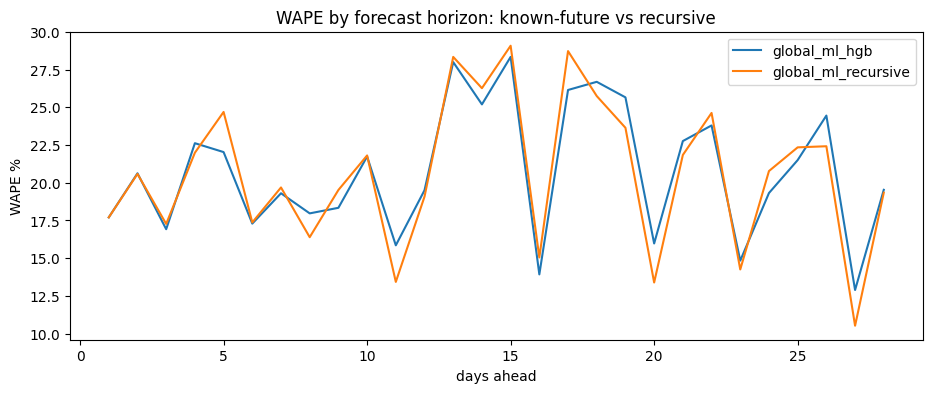

In [12]:
from clinic_forecast.evaluation import add_horizon

by_horizon = evaluate_forecasts(
    add_horizon(modes, origin=final_fold.train_end), group_cols=["horizon_days"]
)
pivot = by_horizon.pivot(index="horizon_days", columns="model", values="wape")

fig, ax = plt.subplots()
for column in pivot.columns:
    ax.plot(pivot.index, pivot[column], label=column)
ax.set_title("WAPE by forecast horizon: known-future vs recursive")
ax.set_xlabel("days ahead")
ax.set_ylabel("WAPE %")
ax.legend()
plt.show()

The two modes are nearly indistinguishable here, and the horizon curve shows
why: the model leans on stable weekly structure and long rolling means rather
than precise recent levels, so feeding predictions back as lags barely moves
the inputs. That is a *property of this demand process*, not a general law —
when demand shifts level abruptly (episode onsets), early forecast errors do
propagate, and the recursive curve would separate. The honest summary: on this
network, deployment-mode accuracy matches the backtest number, and prediction
intervals (next on the roadmap) should be calibrated on recursive errors so
that any future gap is absorbed automatically.

## Prediction intervals: split conformal calibration

A point forecast answers "what do we expect?"; staffing needs "how wrong
could we be?". Split conformal prediction turns past out-of-sample residuals
into intervals with a guaranteed long-run coverage level, with no
distributional assumptions about the model's errors.

Setup: residuals from folds 1-2 (genuinely out-of-sample) form the
calibration set; intervals are evaluated on fold 3, which the calibration
never saw. Calibration is **grouped by clinic** — noisy clinics earn wider
bands — with a global fallback for groups with too little data.

The honest caveat: conformal validity assumes calibration and future
residuals are exchangeable. Demand episodes violate this locally (errors
cluster in time), so coverage on any single month can deviate from the
nominal 90% even when the long-run guarantee holds.

In [13]:
from clinic_forecast.intervals import ConformalIntervals

calibration = scored_folds[
    (scored_folds["model"] == "global_ml_hgb") & (scored_folds["fold"] < last_fold_id)
]
conformal = ConformalIntervals(coverage=0.9, group_col="clinic_id").fit(calibration)
with_intervals = conformal.apply(last_scored)

interval_quality = evaluate_forecasts(
    with_intervals, group_cols=["clinic_id"], lower_col="y_lower", upper_col="y_upper"
)
overall = evaluate_forecasts(with_intervals, lower_col="y_lower", upper_col="y_upper")
print(f"Realised coverage on the held-out fold: {overall.loc[0, 'coverage']:.0%} "
      f"(target 90%), mean width {overall.loc[0, 'interval_width']:.1f} visits")
interval_quality[["clinic_id", "wape", "coverage", "interval_width"]].round(2)

Realised coverage on the held-out fold: 96% (target 90%), mean width 87.5 visits


,clinic_id,wape,coverage,interval_width
0,CLINIC_001,25.84,0.93,70.49
1,CLINIC_002,17.97,0.96,141.70
2,CLINIC_003,29.23,0.96,36.47
3,CLINIC_004,25.86,1.00,95.30
4,CLINIC_005,28.75,0.89,38.64
5,CLINIC_006,23.77,0.96,80.83
6,CLINIC_007,19.05,0.93,89.30
7,CLINIC_008,20.51,1.00,53.21
8,CLINIC_009,26.19,0.82,72.20
9,CLINIC_010,20.84,1.00,144.92


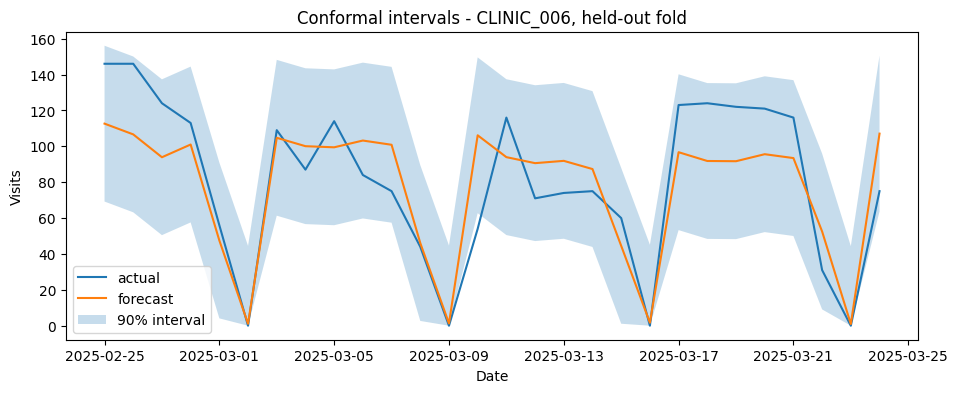

In [14]:
mid_clinic = clinic_metrics.iloc[len(clinic_metrics) // 2]["clinic_id"]
frame = with_intervals[with_intervals["clinic_id"] == mid_clinic]

fig, ax = plt.subplots()
ax.plot(frame["date"], frame["visits"], label="actual")
ax.plot(frame["date"], frame["y_pred"], label="forecast")
ax.fill_between(frame["date"], frame["y_lower"], frame["y_upper"],
                alpha=0.25, label="90% interval")
ax.set_title(f"Conformal intervals - {mid_clinic}, held-out fold")
ax.set_xlabel("Date")
ax.set_ylabel("Visits")
ax.legend()
plt.show()

Three things to verify in the table and plot:

- **Average coverage at or above 90%.** The guarantee holds on data the
  calibration never saw; here it lands a few points *above* target because
  the calibration folds were somewhat noisier than the held-out fold —
  the error in the conservative direction, costing width rather than risk.
- **Per-clinic coverage varies.** Some clinics over- or under-cover on this
  specific month — the episode caveat in practice. Monitoring coverage drift
  per clinic is a planned production check.
- **Widths differ by clinic.** The grouped calibration assigns the volatile
  clinics visibly wider bands. This is the input the staffing layer needs:
  a per-clinic, data-driven safety margin instead of a flat percentage
  buffer. Notebook 06 uses exactly these upper bounds for conservative
  planning.

## Optional: XGBoost

`GlobalMLForecaster(estimator="xgboost")` swaps the estimator if the optional
dependency is installed; on tabular panels of this size the two are usually
within noise of each other.

In [15]:
try:
    import xgboost  # noqa: F401

    xgb_model = GlobalMLForecaster(estimator="xgboost").fit(final_train)
    combined = pd.concat([final_train, final_test], ignore_index=True)
    xgb_pred = xgb_model.predict_known_future(combined)
    xgb_scored = final_test.merge(
        xgb_pred[xgb_pred["date"] >= final_fold.test_start][
            ["clinic_id", "date", "forecast", "model"]
        ],
        on=["clinic_id", "date"], how="inner",
    )
    print(comparison_table(evaluate_forecasts(
        pd.concat([last_scored, xgb_scored], ignore_index=True)
    )))
except ImportError:
    print("XGBoost is not installed. Run `poetry install --with optional` to enable it.")

                      mae    rmse    wape   bias
model                                           
global_ml_xgboost  17.402  24.050  20.441 -1.378
global_ml_hgb      17.606  23.663  20.681 -0.376


## Conclusions

1. One global model serves the entire network, beats seasonal naive on every
   fold, and outperforms per-clinic SARIMAX on the final-fold three-way
   comparison — at constant training cost in the number of clinics.
2. Per-clinic error spread mirrors intrinsic forecastability; what remains is
   episode-driven and irreducible from calendar/lag features.
3. Recursive multi-step forecasting (the deployment reality) costs accuracy
   that grows with horizon. That gap, not the backtest number, is what
   staffing buffers and prediction intervals must absorb.
4. Importance analysis confirms the model leans on recent history and
   calendar structure, with marketing as a secondary signal — consistent with
   the EDA in notebook 02.